In [ ]:
!pip install kagglehub scikit-image


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import heapq
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import kagglehub


In [ ]:
# Download dataset
dataset_path = kagglehub.dataset_download("pavansanagapati/images-dataset")
print("Dataset downloaded at:", dataset_path)

# Get all images
all_images = []
for root, _, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            all_images.append(os.path.join(root, file))

all_images.sort()
print(f"Total images found: {len(all_images)}")


Using Colab cache for faster access to the 'images-dataset' dataset.
Dataset downloaded at: /kaggle/input/images-dataset
Total images found: 2036


In [ ]:
# DCT / IDCT
def dct(block):
    return cv2.dct(np.float32(block))

def idct(block):
    return cv2.idct(np.float32(block))

# Huffman classes & functions
class Node:
    def __init__(self, symbol, freq):
        self.symbol = symbol
        self.freq = freq
        self.left = None
        self.right = None
    def __lt__(self, other):
        return self.freq < other.freq

def build_huffman_tree(freqs):
    heap = [Node(sym, f) for sym, f in freqs.items()]
    heapq.heapify(heap)
    while len(heap) > 1:
        n1 = heapq.heappop(heap)
        n2 = heapq.heappop(heap)
        merged = Node(None, n1.freq + n2.freq)
        merged.left, merged.right = n1, n2
        heapq.heappush(heap, merged)
    return heap[0]

def make_codes(node, prefix="", codebook={}):
    if node is None:
        return
    if node.symbol is not None:
        codebook[node.symbol] = prefix
    make_codes(node.left, prefix + "0", codebook)
    make_codes(node.right, prefix + "1", codebook)
    return codebook

def huffman_encode(data):
    freqs = Counter(data)
    tree = build_huffman_tree(freqs)
    codes = make_codes(tree, "", {})
    encoded = "".join([codes[val] for val in data])
    return encoded, codes


In [ ]:
def compress_image(img_path, Q_value=20):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (256,256))  # resize for uniformity
    ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
    Y, Cr, Cb = cv2.split(ycrcb)

    # DCT + Quantization
    Y_shifted = np.float32(Y) - 128
    dct_Y = dct(Y_shifted)
    Q = np.ones_like(dct_Y) * Q_value
    quantized = np.round(dct_Y / Q)

    # Huffman coding
    flat = quantized.flatten().astype(int).tolist()
    encoded, codes = huffman_encode(flat)
    comp_size = len(encoded) / 8  # bytes

    # Decompression
    dequantized = quantized * Q
    rec_Y = idct(dequantized) + 128
    rec_Y = np.clip(rec_Y, 0, 255).astype(np.uint8)
    rec_img_ycrcb = cv2.merge([rec_Y, Cr, Cb])
    rec_img = cv2.cvtColor(rec_img_ycrcb, cv2.COLOR_YCrCb2BGR)

    # Metrics
    orig_size = Y.size
    ratio = orig_size / comp_size
    psnr_val = psnr(Y, rec_Y)
    ssim_val = ssim(Y, rec_Y)

    return rec_img, ratio, comp_size, psnr_val, ssim_val


Compression Ratio: 5.73
Compressed Size (bytes): 11432.12
PSNR: 30.74
SSIM: 0.82


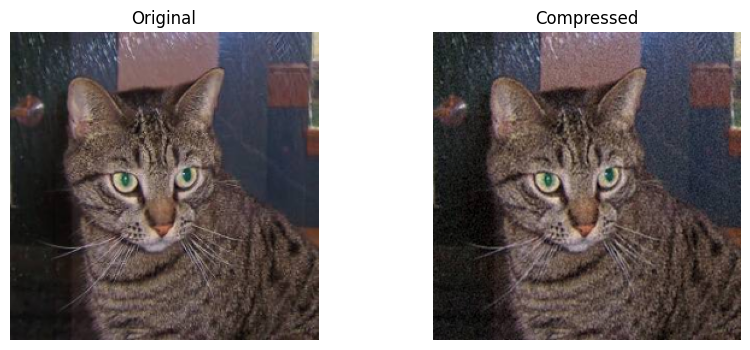

In [ ]:
img_path = all_images[0]  # first image
rec_img, ratio, comp_size, psnr_val, ssim_val = compress_image(img_path, Q_value=30)

print(f"Compression Ratio: {ratio:.2f}")
print(f"Compressed Size (bytes): {comp_size:.2f}")
print(f"PSNR: {psnr_val:.2f}")
print(f"SSIM: {ssim_val:.2f}")

plt.figure(figsize=(10,4))
orig = cv2.imread(img_path)
orig = cv2.resize(orig, (256,256))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(rec_img, cv2.COLOR_BGR2RGB))
plt.title("Compressed")
plt.axis("off")
plt.show()


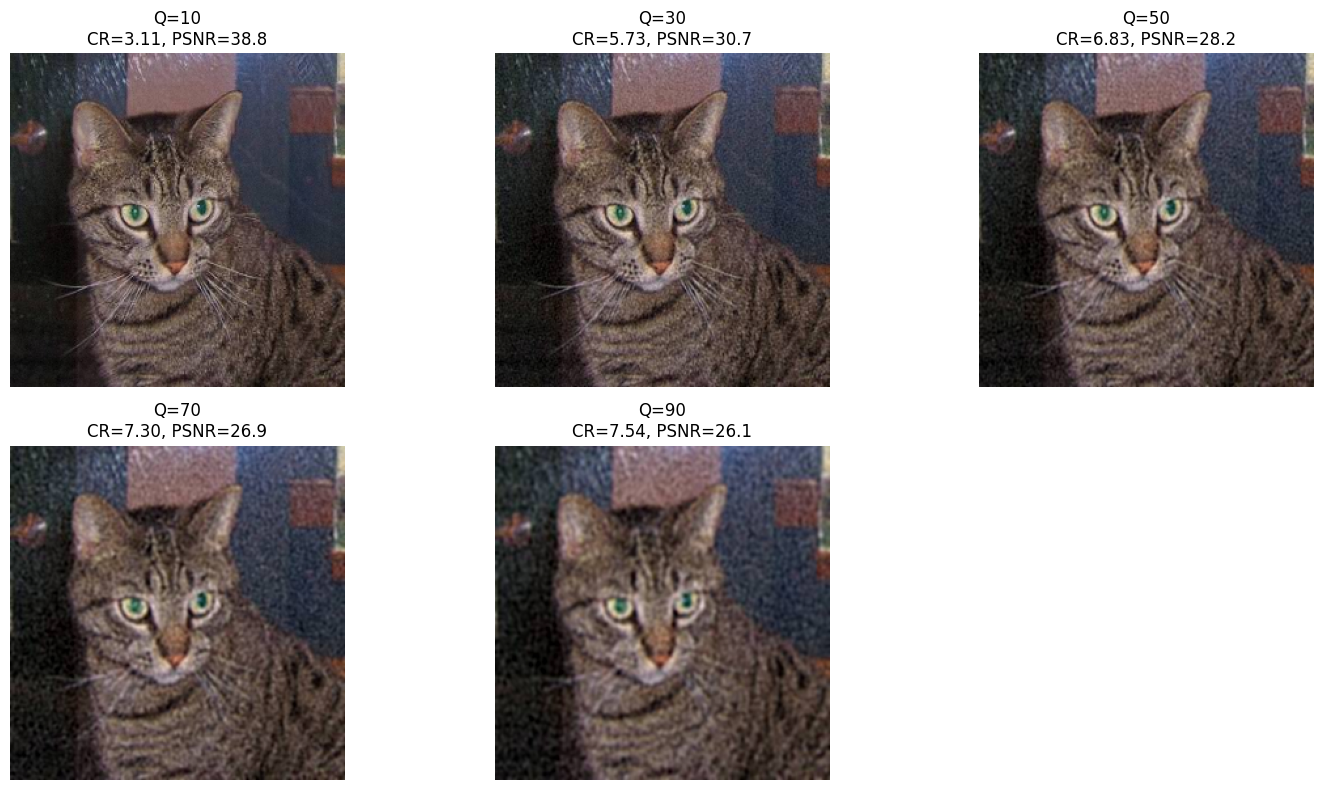

In [ ]:
qualities = [10, 30, 50, 70, 90]
plt.figure(figsize=(15,8))
for i, Q in enumerate(qualities):
    rec_img, ratio, comp_size, psnr_val, ssim_val = compress_image(img_path, Q_value=Q)
    plt.subplot(2,3,i+1)
    plt.imshow(cv2.cvtColor(rec_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Q={Q}\nCR={ratio:.2f}, PSNR={psnr_val:.1f}")
    plt.axis("off")
plt.tight_layout()
plt.show()
